# Ising sampling and contrastive divergence


<div class="note"><span class="note-t">TL;DR</span>
<p>We compare exact chromatic Gibbs updates with bond-local <code>PISING</code> moves, then fit the ring by persistent contrastive divergence. We expose the bond-local bias and recover every coupling and field to within 0.05.</p>
</div>

In this tutorial, we study Ising sampling with Torx's single-site and bond-local kernels.

We validate the Torx `PReset` + `PNOT` Gibbs update directly through `SampleSimulator`, then fit the model parameters with persistent contrastive divergence.

An **Ising model** is a graph with a coupling on every edge and a field at every site. It defines the Boltzmann distribution $\pi(\mathbf{s}) \propto e^{-\beta H(\mathbf{s})}$ over all $2^N$ spin configurations.

This is also a Boltzmann machine (Ackley et al. 1985): a network whose joint distribution is set by pairwise couplings and per-site biases.

<div class="note"><span class="note-t">Where Torx runs</span>
<p>The headline 8-site ring sweep runs on the Torx simulator through <code>torx_chromatic_gibbs</code>, a notebook helper in <code>examples/helpers/_plots_sampling.py</code>. The persistent-contrastive-divergence fit uses a fast host mirror of the same conditional.</p>
</div>

By the end, you'll be able to:

- validate the Torx `PReset` + `PNOT` Gibbs update against its exact local conditional on a single pbit through `SampleSimulator`,
- compare a Torx chromatic Gibbs sweep with the per-edge `PISING` kernel against an exact 8-site reference, and
- fit Ising parameters with persistent contrastive divergence over a fast host mirror of the Gibbs reference.

Locality is what makes fast sampling possible here. Each spin's conditional depends only on its graph neighbors, so a whole color class of conditionally independent sites can update at once. This parallel single-site sampler is **chromatic Gibbs sampling**.

A per-edge circuit uses only bond-local kernels. Those kernels do not factor into the global Gibbs kernel, so they thermalize a different distribution. The moment comparison makes that bias visible.

The 8-site ring stands in for the bars-and-stripes restricted Boltzmann machine in the Torx whitepaper (Verdon et al. 2026). It is small enough to enumerate all $2^8 = 256$ states, which provides an exact Boltzmann reference for each sampler.



## Setup

We set up the helper path, imports, shared plotting style, and figure-saving utility.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
# Locate helpers whether the notebook runs from examples/ or a subdirectory of it.
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
sys.path.insert(0, str(HELPER_DIR))

With the helper path set, import Torx, the numerical libraries, and the notebook helpers:

In [2]:
import jax
import jax.numpy as jnp
import numpy as np

from _notebook_paths import figure_dir
from _notebook_style import (
    apply_notebook_style,
    make_savefig,
)
import _plots_sampling as P_samp
import _plots_schematics as P_sch

from torx.psc import (
    DiscretePCircuit,
    PISING,
    PNOT,
    PReset,
    SampleSimulator,
)

Apply the notebook style, set `SEED`, and wrap figure export:

In [3]:
apply_notebook_style()
FIGURE_DIR = figure_dir(ROOT)
SEED = 123
rng = np.random.default_rng(SEED)


savefig = make_savefig(FIGURE_DIR)

## The Ising model

A spin configuration $\mathbf{s} \in \{-1, +1\}^N$ has energy

$$
H(\mathbf{s}) = \underbrace{-\sum_{(i,j)\in E} J_{ij}\, s_i s_j}_{\vphantom{\big|}\text{bond energy}} \;\underbrace{-\sum_i h_i\, s_i}_{\vphantom{\big|}\text{field energy}} ,
$$

where the first sum runs over the edges $E$ and the second over the sites. The Boltzmann distribution at inverse temperature $\beta$ is

$$
\pi(\mathbf{s}) \propto e^{-\beta H(\mathbf{s})} .
$$

Single-site Gibbs sampling resamples one spin at a time from its exact conditional. For site $i$ with neighbors $N(i)$, we write the local field

$$
\ell_i = h_i + \underbrace{\sum_{j \in N(i)} J_{ij}\,(2\sigma_j - 1)}_{\vphantom{\big|}\text{neighbor sum}},
\qquad
\pi(\sigma_i = 1 \mid \sigma_{N(i)}) = \frac{1}{1 + e^{-2\beta\ell_i}} ,
$$

using bits $\sigma \in \{0, 1\}$ with $s = 2\sigma - 1$. The neighbor sum runs only over $N(i)$.

The conditional is a Bernoulli whose logit (the log-odds of the spin being up) is $2\beta\ell_i$, and this one-site conditional is all the sampler needs.

## The per-site update

A single Gibbs update erases the current spin, then resamples it from the conditional above. In Torx, `PReset` drives the pbit toward `0` regardless of its current value, and `PNOT` flips it with probability $\sigma(2\beta\ell_i)$. Following the Torx whitepaper (Verdon et al. 2026), the per-color update gate is

$$
\mathsf{PColor}_i = \mathsf{PNOT}(2\beta\ell_i) \circ \mathsf{PReset}(\infty).
$$

For a concrete check, build this pair on one pbit with target probability $p = 0.73$:

In [4]:
# Choose a target Bernoulli probability for the one-pbit check.
p_one = 0.73

# Gates carry only their site index; parameters live in `probe_thetas`,
# aligned with the gate order: PReset drives strongly to 0, then PNOT flips
# with probability sigmoid(logit) = p_one.
probe_kernel = DiscretePCircuit(
    [
        PReset(0),
        PNOT(0),
    ]
)
probe_thetas = [
    jnp.array([12.0]),
    jnp.array([float(np.log(p_one / (1.0 - p_one)))]),
]

Draw the circuit. It shows `PReset` followed by the conditional `PNOT` flip:

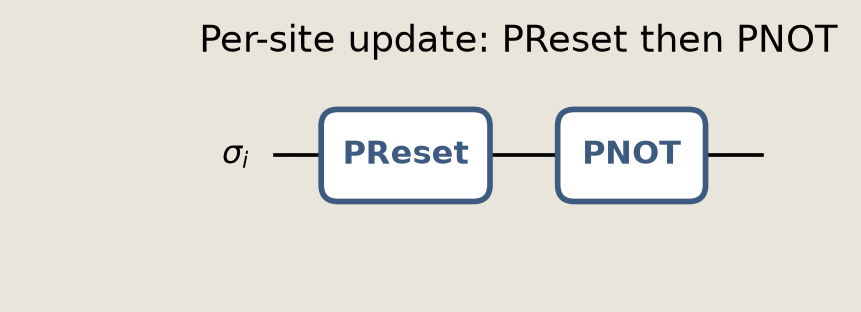

In [5]:
fig_probe = P_sch.draw_pcircuit(
    probe_kernel,
    wire_labels=[r"$\sigma_i$"],
    title="Per-site update: PReset then PNOT",
)
savefig(fig_probe, "06_site_update_circuit")

The two gates erase the current spin, then resample it with the conditional probability.

Sample the one-pbit kernel to check that the empirical mean matches `p_one` within a tolerance of `0.04`:

In [6]:
probe_sim = SampleSimulator(num_samples=2000)
probe_circuit = probe_sim.build_circuit(probe_kernel, probe_thetas)
probe = float(
    np.asarray(
        probe_sim.sample(
            probe_circuit, jnp.array([1], dtype=jnp.int32), jax.random.key(SEED)
        )
    ).mean()
)

np.testing.assert_allclose(probe, p_one, atol=0.04)
print(f"target p = {p_one:.2f}  |  sampled mean = {probe:.3f}")

target p = 0.73  |  sampled mean = 0.741


## Chromatic Gibbs sampling on a ring

The ring has $N = 8$ sites, one pbit per site, one $J_{ij}$ per edge, and one $h_i$ per site.

We color the sites by parity: evens in one color, odds in the other. No neighboring sites share a color, so all sites of one color can update at once while conditioned on the other color.

In [7]:
N = 8
beta = 1.5
ring_edges = [(i, (i + 1) % N) for i in range(N)]
J_true = np.array([0.65, -0.40, 0.55, 0.45, -0.35, 0.50, 0.30, -0.45])
h_true = np.array([0.10, -0.15, 0.05, 0.12, -0.10, 0.08, -0.04, 0.02])
colors = [np.arange(0, N, 2), np.arange(1, N, 2)]

Enumerate all 256 states to build the exact Boltzmann reference and its moments:

In [8]:
def state_index(bits):
    # Map each bit row to the histogram bin used by np.bincount.
    return bits @ (2 ** np.arange(N - 1, -1, -1))


# Enumerate bit states so the exact reference is available for comparison.
states = ((np.arange(2**N)[:, None] >> np.arange(N - 1, -1, -1)) & 1).astype(int)
spins = 2 * states - 1
energy = (
    -np.array(
        [J_true[e] * spins[:, i] * spins[:, j] for e, (i, j) in enumerate(ring_edges)]
    ).sum(0)
    - spins @ h_true
)
exact = np.exp(-beta * energy)
exact /= exact.sum()
exact_mag = (exact[:, None] * spins).sum(axis=0)
exact_corr = np.array(
    [float((exact * spins[:, i] * spins[:, j]).sum()) for (i, j) in ring_edges]
)

np.testing.assert_allclose(exact.sum(), 1.0, atol=1e-10)
print(f"exact Boltzmann: {len(exact)} states, peak = {exact.max():.4f}")

exact Boltzmann: 256 states, peak = 0.0700


Draw the ring to see the two-color structure used by the parallel Gibbs sweep. The even and odd color classes use distinct outlines, and the dark incident edges mark the local field for $s_2$:

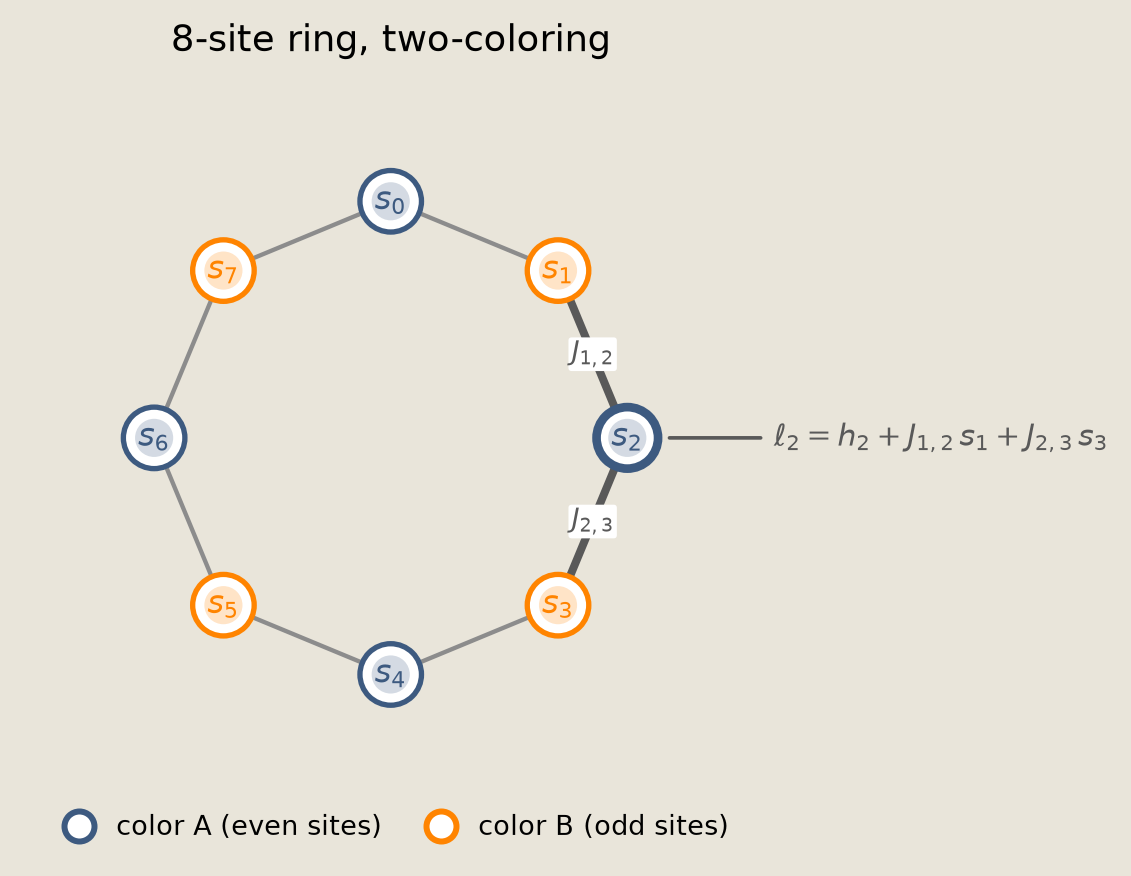

In [9]:
fig = P_sch.plot_chromatic_ring(N=N, ring_edges=ring_edges, colors=colors)
savefig(fig, "06_chromatic_ring")

The highlighted edges at $s_2$ show how narrow each conditional is: a site only reads its two ring neighbors.

Run 6000 independent chains for 240 sweeps with the notebook helper `torx_chromatic_gibbs`, which drives every single-site update through the Torx `PNOT`-from-zero kernel on `SampleSimulator` (seed the pbit to 0, then `PNOT` to the conditional probability, the same Gibbs conditional as the `PReset` + `PNOT` probe we validated above). Its claim-bearing core is excerpted from `examples/helpers/_plots_sampling.py`:

```python
def torx_chromatic_gibbs(init_bits, J, h, *, N, beta, colors, sweeps, key):
    ...
    sim = SampleSimulator(num_samples=1)
    base = sim.build_circuit(
        DiscretePCircuit([PNOT(0)]),
        [jnp.array([0.0])],
    )

    def sample_bit(logit, bit_key):
        # fold the per-chain conditional logit into the PNOT gate theta
        thetas = base.thetas.at[0, 0].set(logit)
        circ = eqx.tree_at(lambda c: c.thetas, base, thetas)
        # seed 0 so PNOT(p) draws Bernoulli(p), the exact one-site conditional
        out = sample_circuit(
            circ, jnp.zeros(1, dtype=jnp.int32), bit_key, num_samples=1
        )[0]
        return out[0, 0]

    sample_bits = jax.vmap(sample_bit)
```

Each chain's conditional logit $2\beta\ell_i$ is folded into the `PNOT` gate theta and `sample_bit` is vmapped over every chain and color site. Then compare the empirical distribution and moments with the exact reference through the total variation distance, which measures how far apart two distributions are:

In [10]:
num_chains = 6000
# Start many independent chains so the histogram estimate is stable.
chains = rng.integers(0, 2, size=(num_chains, N))
# Every single-site update is sampled through the Torx PNOT-from-zero kernel.
gibbs_samples = P_samp.torx_chromatic_gibbs(
    chains,
    J_true,
    h_true,
    N=N,
    beta=beta,
    colors=colors,
    sweeps=240,
    key=jax.random.key(SEED),
)

empirical = np.bincount(state_index(gibbs_samples), minlength=2**N) / num_chains
tv_distance = 0.5 * np.abs(empirical - exact).sum()
gibbs_mag, gibbs_corr = P_samp.moments(gibbs_samples, ring_edges)

assert tv_distance < 0.08, f"TV = {tv_distance:.4f} (expected < 0.08)"
print(f"Torx chromatic Gibbs TV from exact Boltzmann = {tv_distance:.4f}  (< 0.08)")

Torx chromatic Gibbs TV from exact Boltzmann = 0.0634  (< 0.08)


## Per-edge PISING

The bond-local alternative thermalizes one edge at a time.

The `PISING` operation, constructed as `PISING([i, j])` with the per-gate theta `[J, h_i, h_j, beta, dt]` supplied separately, is the column-stochastic Glauber kernel (single-spin-flip dynamics) on the two incident spins. Column-stochastic means every column of transition probabilities sums to one. Its transition matrix is

$$
P = \exp(Q\,\Delta t),
$$

where $Q$ is the single-spin-flip generator (the matrix of instantaneous flip rates) of the bond energy $E(s_i, s_j) = -J s_i s_j - h_i s_i - h_j s_j$. Here $\Delta t$ is the integration time step, named `pising_dt` in the next cell.

We place one gate on each ring edge and split each site's field in half so the two incident bonds sum back to $h_i$.

Each gate sees only its two incident spins, so taken alone its stationary distribution is the split two-spin Boltzmann law for that bond. The composed sweep walks overlapping edges in sequence; the composition does not have the global Boltzmann distribution as its stationary law. It induces a biased global sampler that we measure empirically against the exact ring below.

In [11]:
pising_dt = 0.45

# Gates are structure only (site pair); the [J, h1, h2, beta, dt] parameters
# live in `ring_pising_thetas`, aligned with the gates. Split each site field
# across the two bonds that touch it so the incident bonds sum back to h_i.
ring_pising_gates = [PISING([int(i), int(j)]) for (i, j) in ring_edges]
ring_pising_thetas = [
    jnp.array([J_true[e], h_true[i] / 2.0, h_true[j] / 2.0, beta, pising_dt])
    for e, (i, j) in enumerate(ring_edges)
]

ring_mats = np.asarray(
    [
        np.asarray(g.get_matrix(theta))
        for g, theta in zip(ring_pising_gates, ring_pising_thetas)
    ]
)
# Each PISING gate is column-stochastic, so columns sum to one.
np.testing.assert_allclose(ring_mats.sum(axis=-2), 1.0, atol=1e-6)

Draw a representative circuit slice, showing the first three of eight bond gates for legibility. The full sweep places one `PISING` gate on every ring edge:

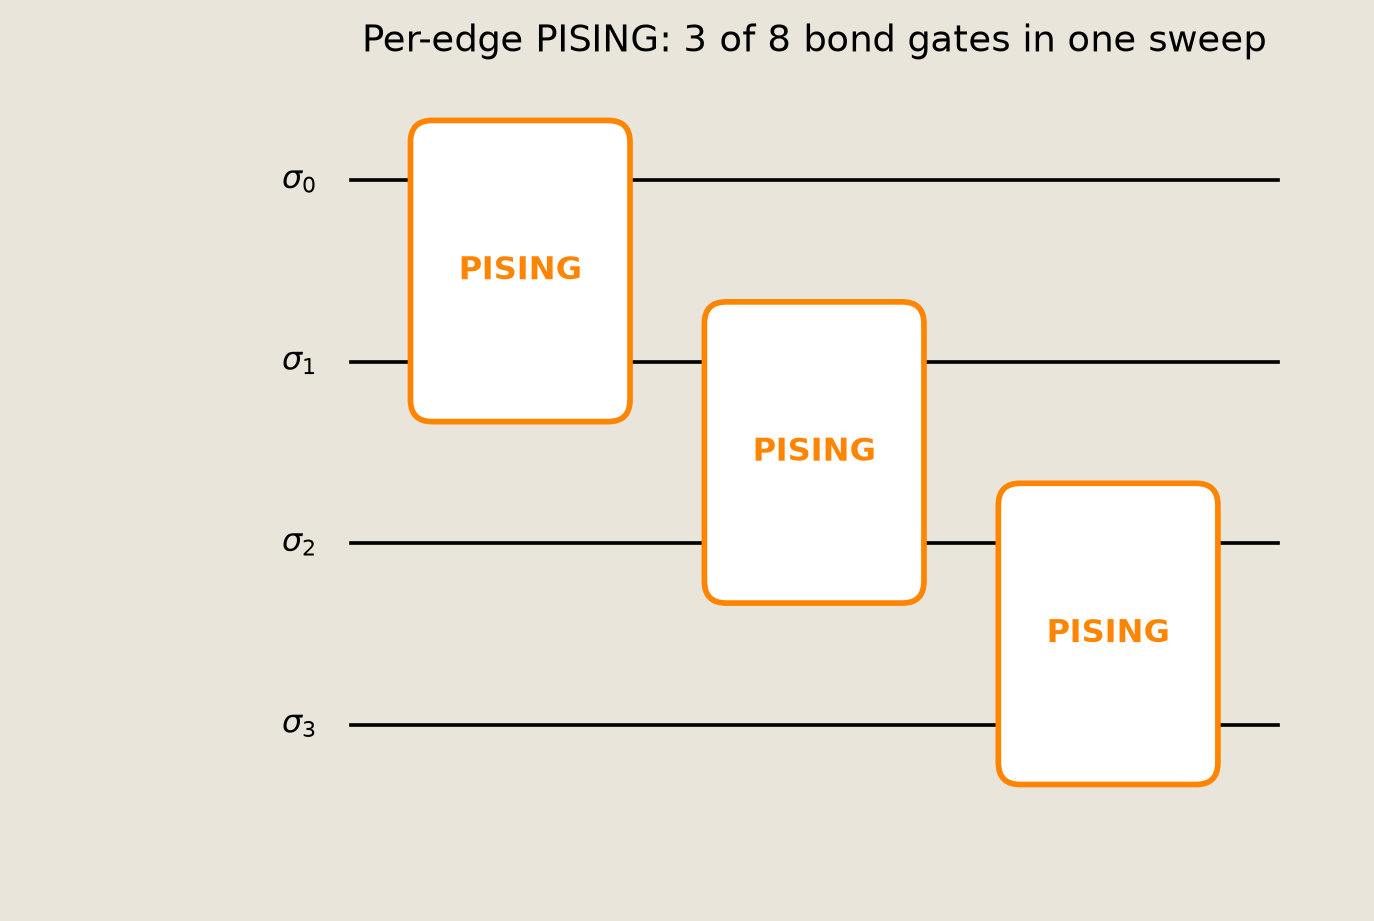

In [12]:
slice_gates = [PISING([e, e + 1]) for e in range(3)]
# no reps annotation: this is a 3-of-8 excerpt of one sweep, not the repeated unit
fig_pising = P_sch.draw_pcircuit(
    DiscretePCircuit(slice_gates),
    wire_labels=[rf"$\sigma_{i}$" for i in range(4)],
    title="Per-edge PISING: 3 of 8 bond gates in one sweep",
)
savefig(fig_pising, "06_pising_ring_circuit")

The full sweep repeats this two-spin bond gate around every edge of the ring.

Sample the per-edge ring with `pising_ring_samples`, a notebook helper that walks the transition matrices above on the host. Compute moments and a total variation distance, and compare both against chromatic Gibbs sampling:

In [13]:
pising_sweeps = 300
pising_num_chains = 4000
pising_samples = P_samp.pising_ring_samples(
    ring_mats,
    N=N,
    ring_edges=ring_edges,
    num_samples=pising_num_chains,
    sweeps=pising_sweeps,
    seed=SEED + 1,
)

pising_mag, pising_corr = P_samp.moments(pising_samples, ring_edges)
pising_hist = (
    np.bincount(state_index(pising_samples), minlength=2**N) / pising_num_chains
)
pising_tv = 0.5 * np.abs(pising_hist - exact).sum()

print(f"per-edge PISING TV from exact Boltzmann = {pising_tv:.4f}")
print(f"  chromatic Gibbs TV (for comparison)   = {tv_distance:.4f}")

per-edge PISING TV from exact Boltzmann = 0.4020
  chromatic Gibbs TV (for comparison)   = 0.0634


In total variation the per-edge sweep sits about six times farther from the exact Boltzmann distribution than the chromatic Gibbs sweep (0.4020 against 0.0634). That one number summarizes the bond-local bias.

### Comparing the moments

The plot compares the per-site magnetizations $\langle s_i\rangle$ and the per-edge correlations $\langle s_i s_j\rangle$ for the exact reference, chromatic Gibbs sampling, and the per-edge `PISING` operation.

Chromatic Gibbs sampling tracks the exact moments. The per-edge `PISING` operation gets most signs right but underestimates the magnitudes; at $s_6$, where the exact magnetization is nearly zero, even the sign flips.

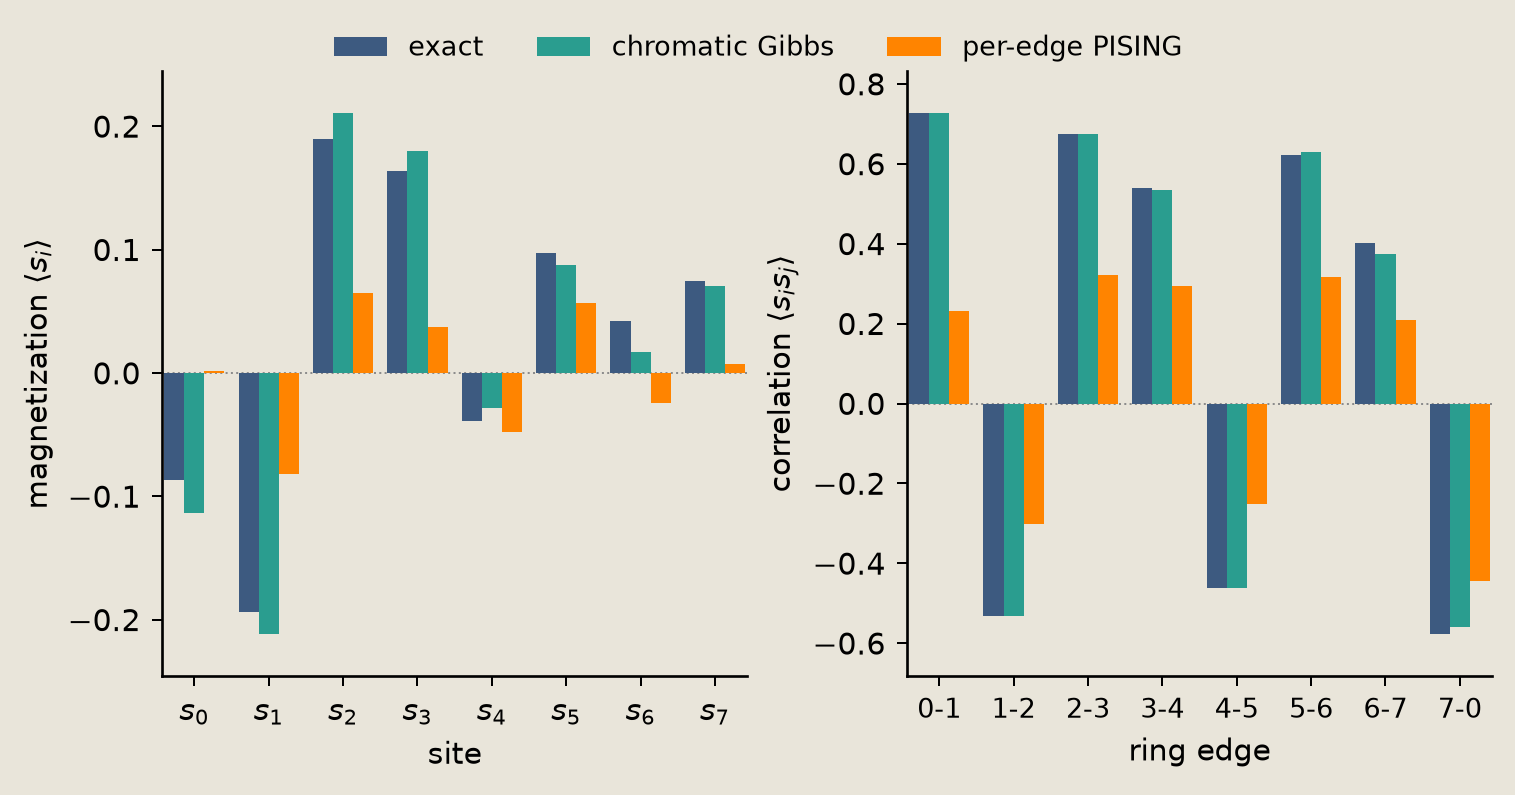

In [14]:
fig = P_samp.plot_ring_marginals(
    N=N,
    ring_edges=ring_edges,
    exact_mag=exact_mag,
    gibbs_mag=gibbs_mag,
    pising_mag=pising_mag,
    exact_corr=exact_corr,
    gibbs_corr=gibbs_corr,
    pising_corr=pising_corr,
)
savefig(fig, "06_ring_ising_marginals")

The smaller magnitudes are the bond-local bias: thermalizing one edge at a time loses the longer-range structure that fixes each moment's size.

## Persistent contrastive divergence

**Persistent contrastive divergence** (Tieleman 2008) keeps Gibbs chains running instead of resetting them from data. At each step, it contrasts their moments with the data moments. The log-likelihood gradients are the moment differences:

$$
\partial_{J_{ij}}\log\mathcal{L} = \beta\bigl(\langle s_i s_j\rangle_{\text{data}} - \langle s_i s_j\rangle_{\text{model}}\bigr),
\qquad
\partial_{h_i}\log\mathcal{L} = \beta\bigl(\langle s_i\rangle_{\text{data}} - \langle s_i\rangle_{\text{model}}\bigr).
$$

We draw 2048 training samples from the exact Boltzmann distribution.

In [15]:
num_data = 2048
# dedicated stream so the fit is reproducible regardless of upstream sampler draws
fit_rng = np.random.default_rng(SEED)
# Draw synthetic data from the exact reference before fitting.
data_idx = fit_rng.choice(2**N, size=num_data, p=exact)
data_bits = states[data_idx]
data_mag, data_corr = P_samp.moments(data_bits, ring_edges)

Start the chains from a flat model, $J = h = 0$, with learning rate $0.08$:

In [16]:
J = np.zeros(N)
h = np.zeros(N)
persistent = fit_rng.integers(0, 2, size=(num_data, N))
lr = 0.08

Each step runs 2 sweeps of the host-reference helper `chromatic_gibbs`, then nudges $J$ and $h$ by the data-minus-model moment gap:

In [17]:
for step in range(300):
    # Keep persistent chains instead of resetting them to data each step. The fit
    # uses the fast host mirror of the kernel validated on Torx above.
    persistent = P_samp.chromatic_gibbs(
        persistent, J, h, N=N, beta=beta, colors=colors, sweeps=2, rng=fit_rng
    )
    model_mag, model_corr = P_samp.moments(persistent, ring_edges)
    h += lr * beta * (data_mag - model_mag)
    J += lr * beta * (data_corr - model_corr)

After 300 steps, check the learned parameters against the truth:

In [18]:
np.testing.assert_allclose(J, J_true, atol=0.05)
np.testing.assert_allclose(h, h_true, atol=0.05)
print(f"max |J_learned - J_true| = {np.max(np.abs(J - J_true)):.4f}")
print(f"max |h_learned - h_true| = {np.max(np.abs(h - h_true)):.4f}")

max |J_learned - J_true| = 0.0373
max |h_learned - h_true| = 0.0386


### Parameter recovery

The parity panels plot the learned couplings and fields against the true values after 300 persistent contrastive divergence steps. Points on the dotted diagonal indicate exact recovery.

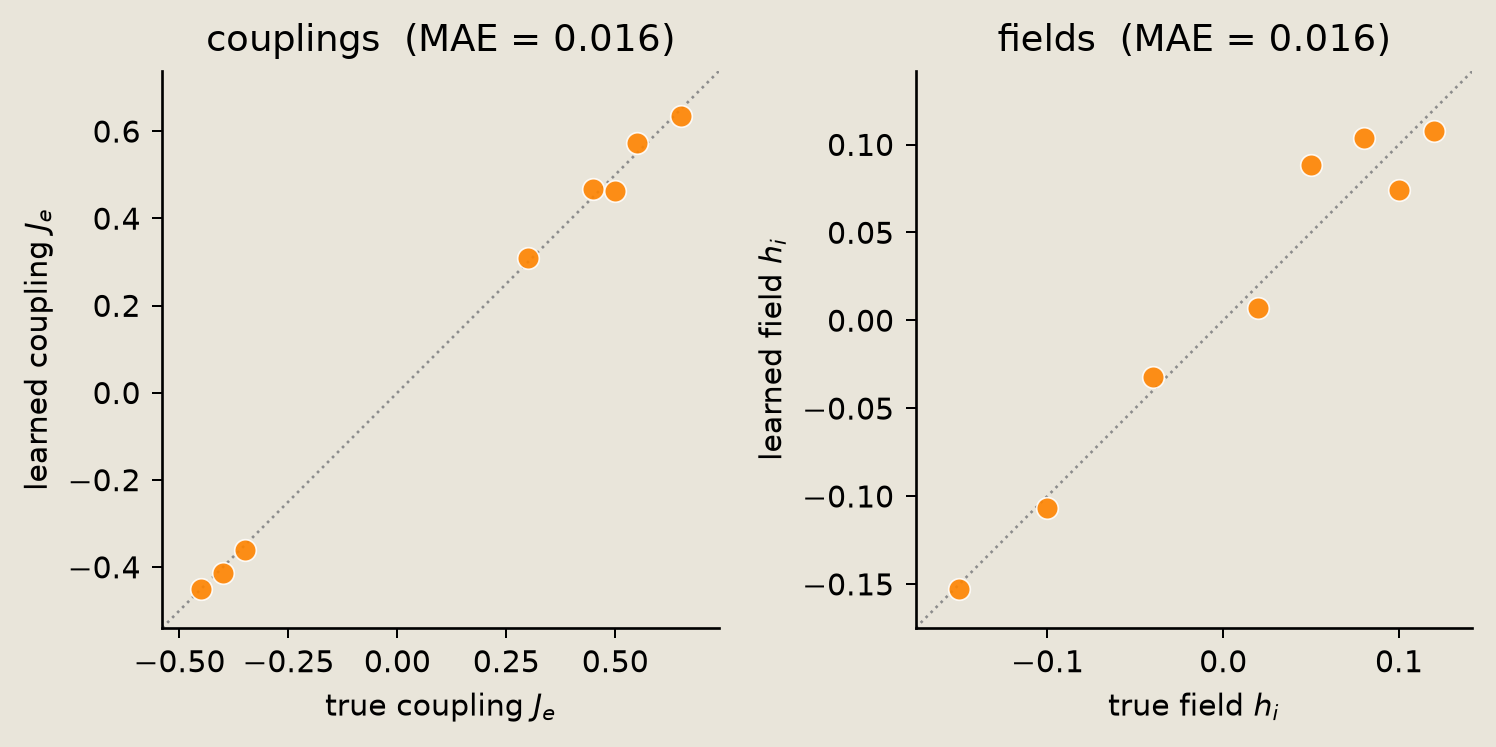

In [19]:
fig = P_samp.plot_pcd_recovery(J_true=J_true, J=J, h_true=h_true, h=h)
savefig(fig, "06_pcd_recovery")

Points hugging the diagonal show that the fit recovered both the couplings and the fields.

## Verification

The quantitative checks ran as inline assertions above; print their summary in one place:

In [20]:
print("all checks passed")
print(f"  chromatic Gibbs TV   = {tv_distance:.4f}  (< 0.08)")
print(f"  per-edge PISING TV   = {pising_tv:.4f}")
print(f"  max |J - J_true|     = {np.max(np.abs(J - J_true)):.4f}")
print(f"  max |h - h_true|     = {np.max(np.abs(h - h_true)):.4f}")

all checks passed
  chromatic Gibbs TV   = 0.0634  (< 0.08)
  per-edge PISING TV   = 0.4020
  max |J - J_true|     = 0.0373
  max |h - h_true|     = 0.0386


## Conclusion

We compared the exact, chromatic Gibbs, per-edge `PISING`, and trained Ising models on an 8-site ring.

- The per-site Gibbs conditional is a Bernoulli with logit $2\beta\ell_i$; we validated it in Torx with a `PReset`-then-`PNOT` probe.
- The headline two-color chromatic sweep runs on Torx (`torx_chromatic_gibbs`): it draws each site through the `PNOT`-from-zero kernel (a deterministic reset to 0 then `PNOT`, the same conditional as the probe) and samples the ring to within total variation 0.08 of the exact Boltzmann distribution. We reserve the fast host mirror for the persistent-contrastive-divergence fit.
- The per-edge `PISING` operation thermalizes one bond at a time, so it is biased: it gets most moment signs right but underestimates the magnitudes.
- Persistent contrastive divergence fits the ring from a flat start, recovering the couplings and fields to within 0.05 in 300 steps.

Next, [`07_discrete_diffusion.ipynb`](07_discrete_diffusion.ipynb) builds a denoising prior from the same edge-local primitives, and [`08_stochastic_convolutional_networks.ipynb`](08_stochastic_convolutional_networks.ipynb) carries those primitives into a convolutional network.

## References

1. Ackley, D.H., Hinton, G.E., Sejnowski, T.J. 1985. [*A learning algorithm for Boltzmann machines*](https://www.cs.toronto.edu/~hinton/absps/cogscibm.pdf). Cognitive Science 9(1), 147-169. The Boltzmann-machine learning algorithm whose pairwise-coupling energy model the ring realizes.
2. Tieleman, T. 2008. [*Training restricted Boltzmann machines using approximations to the likelihood gradient*](https://www.cs.toronto.edu/~tijmen/pcd/pcd.pdf). ICML 2008, 1064-1071. The persistent contrastive divergence scheme used in the training section.
3. Verdon, G., Tyrpak, L., Lockwood, O., Morton, S., Neagoe, A., Sugolov, A., MacCormack, I., Amico, M. 2026. *A Framework for Stochastic Differentiable Programming*. White paper, [Extropic](https://github.com/extropic-ai/torx). The Torx whitepaper whose bars-and-stripes restricted Boltzmann machine the ring stands in for.

